# Numerische Ableitung


## Übungsblatt


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from scipy.optimize import root_scalar


def deriv(f, x, h):
    """
    Ableitung einer Funktion f an der/n Stelle/n x mit Schrittweite h,
    berechnet mit dem zentralen Differenzenquotienten.
    """
    return (f(x + h) - f(x - h)) / (2 * h)


def deriv_data(x_data, y_data):
    """
    Ableitung einer Funktion, die durch Datenpunkte gegeben ist.
    """
    dydx = np.diff(y_data) / np.diff(x_data)
    yprime = np.empty_like(y_data)
    yprime[0] = dydx[0]
    yprime[-1] = dydx[-1]
    yprime[1:-1] = (dydx[:-1] + dydx[1:]) / 2
    return yprime

### Aufgabe 1: Jogging


In der Datei `jogging.csv` sind die Daten einer Joggingrunde gespeichert. Die Spalten enthalten folgende Daten:

1. Zeit der Messung in Sekunden
2. Zurückgelegte Distanz in Metern
3. Geschwindigkeit (_engl. pace_) in Minuten pro Meile (1 Meile = 1609.344 Meter)
4. Herzfrequenz in Anzahl Schläge pro Minute

Ziel ist es, die Geschwindigkeit aus der zurückgelegten Distanz und der Zeit zu berechnen und diese mit den Geschwindigkeitsdaten zu vergleichen.

Vorgehen:

1. Lade die ersten drei Spalten aus der Datei `jogging.csv` in die 1D-Arrays `time`, `distance`, `pace`. Die letzte Spalte kann ignoriert werden.
2. Berechne die Geschwindigkeit als Ableitung der zurückgelegten Distanz nach der Zeit. Nutze dazu die passende Funktion aus der Vertiefung, siehe oben.
3. Rechne die berechneten und die gemessenen Geschwindigkeiten in die gleichen Einheiten um: entweder beide in _min/km_ oder beide in _m/s_.
4. Stelle die beiden Geschwindigkeiten im gleichen Diagramm dar. Wähle geeignete Darstellungsbereiche und schreibe die Achsen an (inkl. Einheiten).

Wie gut stimmen die beiden Geschwindigkeiten überein?


C:\Users\hols\AppData\Local\Temp\ipykernel_32676\2418746585.py:5: RuntimeWarning: divide by zero encountered in divide
  speed_from_pace = 1 / pace * 1609.344 / 60


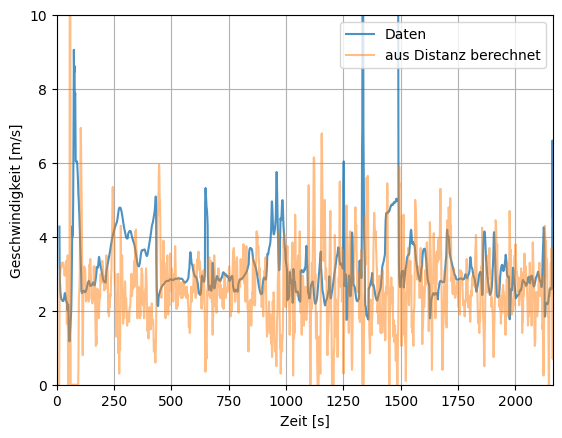

Mittlere Geschwindigkeiten:


(np.float64(3.180133365144171), np.float64(2.560018579935653))

In [2]:
jogging = np.loadtxt("jogging.csv", delimiter=";", skiprows=1, usecols=(0, 1, 2))
time, distance, pace = jogging.T

speed_from_distance = deriv_data(time, distance)
speed_from_pace = 1 / pace * 1609.344 / 60

plt.plot(time, speed_from_pace, label="Daten", alpha=0.8)
plt.plot(time, speed_from_distance, label="aus Distanz berechnet", alpha=0.5)
plt.ylabel("Geschwindigkeit [m/s]")
plt.xlabel("Zeit [s]")
plt.xlim(time.min(), time.max())
plt.ylim(0, 10)
plt.legend()
plt.grid()
plt.show()

print("Mittlere Geschwindigkeiten:")
speed_from_pace[speed_from_pace < np.inf].mean(), speed_from_distance.mean()

### Aufgabe 2: Wasserverbrauch


Wir schauen Daten zum Wasserverbrauch an. Das Ziel ist hier die Ableitung (Änderungsrate des Wasserverbrauchs) einerseits direkt aus den Daten zu berechnen und andererseits, die Daten zuerst zu interpolieren und dann die Ableitung der Interpolationsfunktion zu berechnen.


#### a) Daten importieren und darstellen

Importiere die Daten in der Datei `wasserverbrauch.csv`. Stelle den Wasserverbrauch als Funktion der Zeit dar.


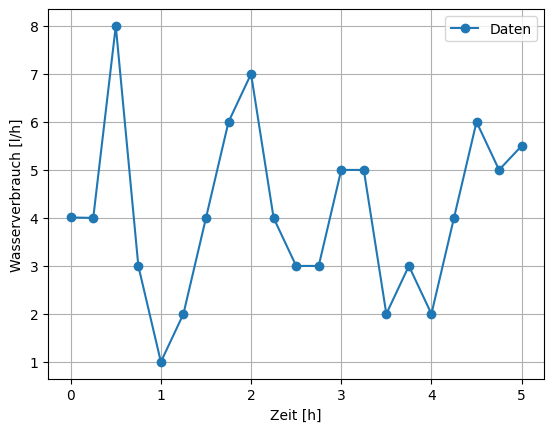

In [3]:
x_data, y_data = np.loadtxt("wasserverbrauch.csv", delimiter=";", skiprows=1).T

plt.plot(x_data, y_data, "o-", label="Daten")
plt.xlabel("Zeit [h]")
plt.ylabel("Wasserverbrauch [l/h]")
plt.legend()
plt.grid()
plt.show()

#### b) Interpolieren


Nun interpolieren wir die Daten an 500 Stellen im Bereich $x \in [0, 5]$.

Für die kubische Spline-Interpolation verwenden wir [`scipy.interpolate.make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html) mit natürlichen Randbedingungen.

Stelle nun die interpolierten Werte (als verbundene Linie) und die Messwerte (als rote Punkte) zusammen dar.


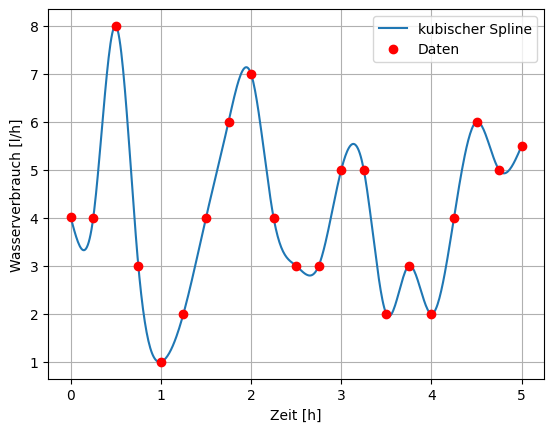

In [4]:
spline = make_interp_spline(x_data, y_data, bc_type="natural")
x_spline = np.linspace(0, 5, 500)
y_spline = spline(x_spline)

plt.plot(x_spline, y_spline, label="kubischer Spline")
plt.plot(x_data, y_data, "ro", label="Daten")
plt.xlabel("Zeit [h]")
plt.ylabel("Wasserverbrauch [l/h]")
plt.legend()
plt.grid()
plt.show()

#### c) Ableiten


Hier soll die Änderungsrate (Ableitung) des Wasserverbrauchs berechnet werden. Die beiden Funktionen `deriv` und `deriv_data` sind aus der Einarbeitung und Vertiefung bekannt. Sie sind zuoberst im Übungsblatt bereits definiert. Schaue sie nochmals an und mache dir klar, wie sie funktionieren und angewendet werden.

1. Berechne die numerische Ableitung der Interpolationsfunktion mit einer sinnvollen Schrittweite (siehe Diskussion in Vertiefung).
2. Berechne die Ableitung ausgehend von den Originaldaten.
3. Stelle den Wasserverbrauch (Spline und Daten wie in Teil b) und darunter dessen Ableitung (aus Spline und aus Daten) grafisch dar.

Benutze auch mal einen linearen oder quadratischen Spline (ohne Angabe des `bc_type`) und beobachte, wie sich die Ableitung ändert.


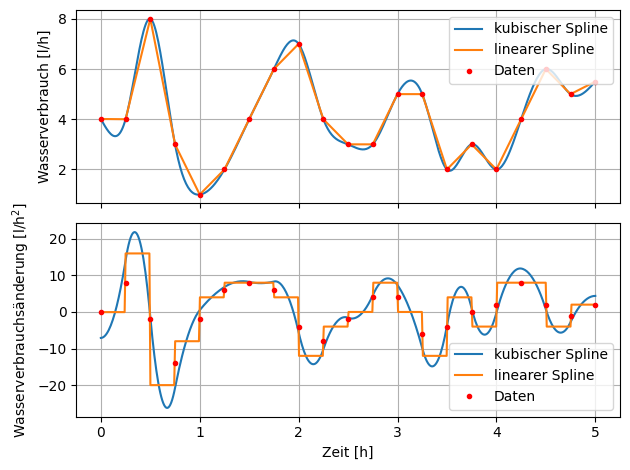

In [5]:
cubic_spline = make_interp_spline(x_data, y_data, bc_type="natural")
linear_spline = make_interp_spline(x_data, y_data, k=1)
x_spline = np.linspace(0, 5, 500)
y_cubic_spline = cubic_spline(x_spline)
y_linear_spline = linear_spline(x_spline)

yprime_cubic_spline = deriv(cubic_spline, x_spline, 5e-6)
yprime_linear_spline = deriv(linear_spline, x_spline, 5e-6)
yprime_data = deriv_data(x_data, y_data)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(x_spline, y_cubic_spline, label="kubischer Spline")
ax1.plot(x_spline, y_linear_spline, label="linearer Spline")
ax1.plot(x_data, y_data, "r.", label="Daten")
ax1.set_ylabel("Wasserverbrauch [l/h]")
ax1.legend()
ax1.grid()

ax2.plot(x_spline, yprime_cubic_spline, label="kubischer Spline")
ax2.plot(x_spline, yprime_linear_spline, label="linearer Spline")
ax2.plot(x_data, yprime_data, "r.", label="Daten")
ax2.set_xlabel("Zeit [h]")
ax2.set_ylabel("Wasserverbrauchsänderung [l/h$^2$]")
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.show()

#### d) Analytische Ableitung der Spline-Interpolation


Eine Spline-Interpolation ist ja eine stückweise definierte Funktion. Die Teilstücke sind Polynome, deren Ableitung analytisch berechnet werden können und auch wieder Polynome sind. Also ist die Ableitung eines kubischen Splines ein quadratischer Spline, die Ableitung eines quadratischen Splines ein linearer Spline und die Ableitung eines linearen Splines eine stückweise konstante Funktion (Spline vom Grad 0).

Das [`BSpline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BSpline.html) Objekt, das von der Funktion [`make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html) erzeugt wird, bietet die Methode [`BSpline.derivative`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BSpline.derivative.html). Diese liefert wieder ein [`BSpline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BSpline.html) Objekt, das nun die Ableitung des ursprünglichen Splines repräsentiert.

Bestimme für den kubischen Spline aus Teil b) die analytische Ableitung und vergleiche diese mit der numerischen Ableitung aus Teil c). Stelle darunter den absoluten Fehler der numerischen Ableitung ggü. der Ableitung des Splines dar.


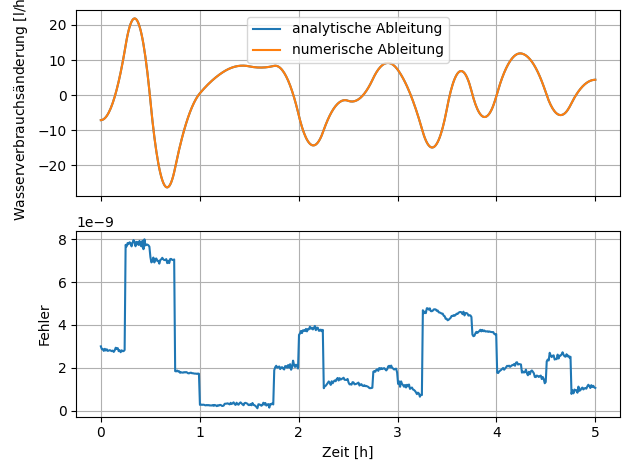

In [6]:
yprime_analytic = cubic_spline.derivative()
yprime_from_analytic = yprime_analytic(x_spline)
D_yprime_numeric = yprime_cubic_spline - yprime_from_analytic

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(x_spline, yprime_from_analytic, label="analytische Ableitung")
ax1.plot(x_spline, yprime_cubic_spline, label="numerische Ableitung")
ax1.set_ylabel("Wasserverbrauchsänderung [l/h$^2$]")
ax1.legend()
ax1.grid()

ax2.plot(x_spline, np.abs(D_yprime_numeric))
ax2.set_xlabel("Zeit [h]")
ax2.set_ylabel("Fehler")
ax2.grid()

plt.tight_layout()
plt.show()

### Aufgabe 3: Bolts Geschwindigkeit


Hierfür schauen wir uns die Daten von Usain Bolts Weltrekord von 2009 an. Diese findet ihr in der Datei `bolt100m.csv`.

Das Ziel hier ist aus Messungen des Weg-Zeit-Diagramms die Geschwindigkeit zu berechnen. Daraus bestimmen wir den Zeitpunkt der maximalen Geschwindigkeit, indem wir die Nullstelle der Beschleunigung bestimmen.


#### a) Daten importieren


Lade die Daten. Gemessen wurde die Zeit $t$ in s (zweite Spalte) zu spezifischen Distanzen $d$ in m (erste Spalte).


In [7]:
d_data, t_data = np.loadtxt("bolt100m.csv", delimiter=",", skiprows=1).T

#### b) Geschwindigkeit (Ableitung) berechnen


1. Berechne die Geschwindigkeit $v$ in m/s, indem Du die numerische Ableitung $v=d'(t)$ mit [`np.gradient`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html) berechnest.
    - _Vorsicht_: Die Funktion [`np.gradient`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html) erwartet als Argumente zuerst die Funktionswerte und dann die Werte der unabhängigen Variable, siehe Beispiel in der Vertiefung und lese die Dokumentation.
2. Stelle $d$ und $v$ als Funktionen von $t$ sinnvoll dar.


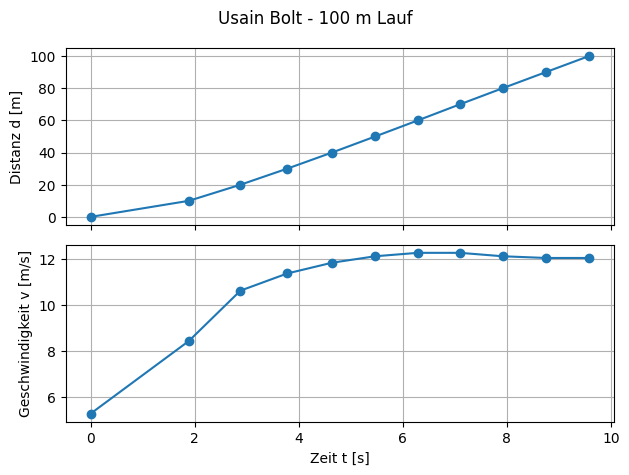

In [8]:
v_data = np.gradient(d_data, t_data)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(t_data, d_data, "o-")
ax1.set_ylabel("Distanz d [m]")
ax1.grid()

ax2.plot(t_data, v_data, "o-")
ax2.set_xlabel("Zeit t [s]")
ax2.set_ylabel("Geschwindigkeit v [m/s]")
ax2.grid()

plt.suptitle("Usain Bolt - 100 m Lauf")
plt.tight_layout()
plt.show()

#### c) Geschwindigkeit interpolieren


Als nächstes ist das Ziel, herauszufinden, wann Bolt seine maximale Geschwindigkeit erreicht hat. Dazu brauchen wir die Ableitung der Geschwindigkeit, also die Beschleunigung $a$. Davon bestimmen wir die Nullstelle. (Erinnere Dich an die Kurvendiskussion in der _Analysis_.)

Nullstellen können wir mit [SciPy](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding) nur von Funktionen und nicht direkt von Daten berechnen. Daher konstruieren wir zuerst eine kubische Spline-Interpolationsfunktion der Geschwindigkeit und nehmen davon die Ableitung. (Alternativ könnten wir die Geschwindigkeit zuerst numerisch ableiten und dann die Beschleunigung interpolieren.)

1. Konstuiere mit [`scipy.interpolate.make_interp_spline`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html) eine Interpolationsfunktion der Geschwindigkeit.
2. Leite diese Funktion mit der Methode [`BSpline.derivative`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BSpline.derivative.html) ab (siehe Aufgabe 2 d) und definiere damit die Beschleunigungsfunktion.
3. Finde die Nullstelle der Beschleulnigung mit einer passenden Methode aus [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html).
4. Stelle die Geschwindigkeit (Daten und Spline) und die Beschleunigung (Spline) in übereinanderliegenden Diagrammen dar. Zeichne die Nullstelle der Beschleunigung und das somit gefundene Maximum der Geschwindigkeit ein.


In [9]:
v_spline = make_interp_spline(t_data, v_data, bc_type="natural")
a_spline = v_spline.derivative()
a_root = root_scalar(a_spline, bracket=[5, 8])
a_root

      converged: True
           flag: converged
 function_calls: 10
     iterations: 9
           root: 6.709476943128242
         method: brentq

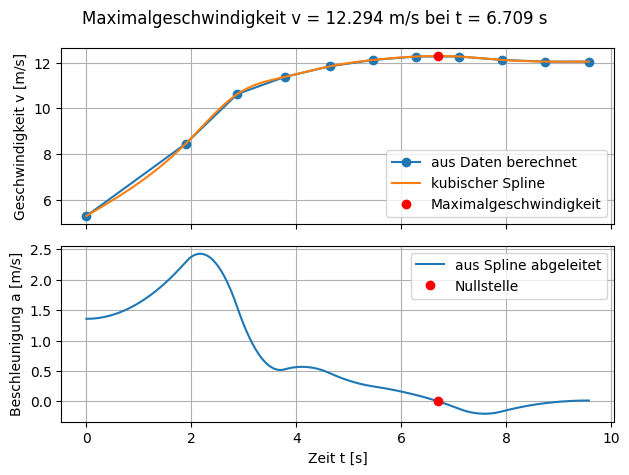

In [10]:
t_max = a_root.root
v_max = v_spline(t_max)

t = np.linspace(t_data.min(), t_data.max(), 500)
v = v_spline(t)
a = a_spline(t)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(t_data, v_data, "o-", label="aus Daten berechnet")
ax1.plot(t, v, "-", label="kubischer Spline")
ax1.plot(t_max, v_max, "ro", label="Maximalgeschwindigkeit")
ax1.set_ylabel("Geschwindigkeit v [m/s]")
ax1.legend()
ax1.grid()
ax2.plot(t, a, "-", label="aus Spline abgeleitet")
ax2.plot(t_max, 0, "ro", label="Nullstelle")
ax2.set_xlabel("Zeit t [s]")
ax2.set_ylabel("Beschleunigung a [m/s]")
ax2.legend()
ax2.grid()
plt.suptitle(f"Maximalgeschwindigkeit v = {v_max:.3f} m/s bei t = {t_max:.3f} s")
plt.tight_layout()
plt.show()

#### d) Geschwindigkeit numerisch ableiten und Beschleunigung interpolieren (optional)

Leite die Geschwindigkeit zuerst numerisch ab und interpoliere die resultierende Beschleunigung. Bestimme davon die Nullstelle. Stelle wiederum Geschwindigkeit und Beschleunigung dar und zeichne die Nullstelle ein. Vergleiche das Ergebnis mit dem aus c).


In [11]:
a_data = np.gradient(v_data, t_data)
a_spline = make_interp_spline(t_data, a_data, bc_type="natural")
a_root = root_scalar(a_spline, bracket=[5, 8])
a_root

      converged: True
           flag: converged
 function_calls: 10
     iterations: 9
           root: 6.669833311440452
         method: brentq

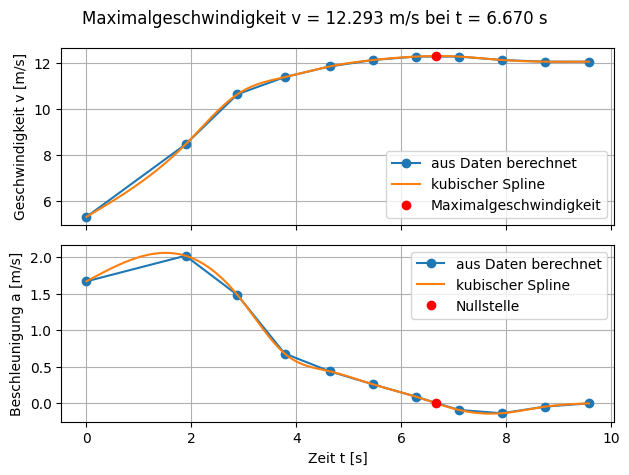

In [12]:
t_max = a_root.root

v_spline = make_interp_spline(t_data, v_data, bc_type="natural")
v_max = v_spline(t_max)

t = np.linspace(t.min(), t.max(), 500)
v = v_spline(t)
a = a_spline(t)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(t_data, v_data, "o-", label="aus Daten berechnet")
ax1.plot(t, v, "-", label="kubischer Spline")
ax1.plot(t_max, v_spline(t_max), "ro", label="Maximalgeschwindigkeit")
ax1.set_ylabel("Geschwindigkeit v [m/s]")
ax1.legend()
ax1.grid()
ax2.plot(t_data, a_data, "o-", label="aus Daten berechnet")
ax2.plot(t, a, "-", label="kubischer Spline")
ax2.plot(t_max, 0, "ro", label="Nullstelle")
ax2.set_xlabel("Zeit t [s]")
ax2.set_ylabel("Beschleunigung a [m/s]")
ax2.legend()
ax2.grid()
plt.suptitle(f"Maximalgeschwindigkeit v = {v_max:.3f} m/s bei t = {t_max:.3f} s")
plt.tight_layout()
plt.show()

Die beiden Vorgehen liefern beinahe das gleiche Ergebnis. Sie unterscheiden sich ab der zweiten Stelle nach dem Komma in der Zeit, und in der dritte Stelle nach dem Komma in der Geschwindigkeit.
